In [50]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Explainable AI
import shap

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [51]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows if needed
pd.set_option('display.max_rows', 100)

# Set plot style
sns.set_style('whitegrid')

# Set figure size
plt.rcParams['figure.figsize'] = (10, 6)

In [52]:
# Load the dataset using semicolon separator
df = pd.read_csv('/kaggle/input/datasets/npbetti/credit-card-dataset/Credit_Card.csv', sep=';')

In [53]:
# Display first 5 rows
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,"RISK_RATING,"
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,"2,"
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,"1,"
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,"1,"
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,"1,"
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,"1,"


In [54]:
# Display column names
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING,']


In [55]:
# Remove extra commas from column names
df.columns = df.columns.str.replace(',', '', regex=False)

# Display cleaned column names
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING']


In [56]:
# Check unique values
print(df['RISK_RATING'].unique())

['2,' '1,' '3,' '1' '2']


In [57]:
# Remove commas from RISK_RATING values
df['RISK_RATING'] = df['RISK_RATING'].astype(str).str.replace(',', '')

# Convert to integer
df['RISK_RATING'] = df['RISK_RATING'].astype(int)

# Check datatype
print(df['RISK_RATING'].dtype)

int64


In [58]:
# Display first 5 rows after cleaning
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


In [59]:
# Check dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (34788, 30)


In [60]:
# Display all column names
print(df.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM',
       'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING'],
      dtype='object')


In [61]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2                   347

In [62]:
# Display statistical summary
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,BILL_AMT_SUM,RISK_RATING
count,34788.000000,3.307900e+04,33021.000000,33054.000000,33055.000000,33033.000000,34788.000000,34788.000000,34788.000000,34788.000000,34788.000000,34788.000000,34788.000000,34788.000000,3.478800e+04,34788.000000,34788.000000,34788.000000,33063.000000,3.304400e+04,34788.000000,34788.000000,34788.000000,34788.000000,34788.000000,3.478800e+04,34788.000000
mean,15006.206939,1.846690e+05,1.604252,1.851243,1.550870,35.518300,-0.045792,-0.156922,-0.185552,-0.239077,-0.283402,-0.306226,51312.956307,49271.123692,4.709650e+04,43303.188082,40385.650655,38955.095493,5772.822551,6.057363e+03,5318.645280,4923.737093,4873.659624,5227.822784,0.191330,2.948152e+05,1.229389
std,8670.802495,2.359319e+05,0.489018,0.790827,0.521464,9.236783,1.103259,1.177451,1.180412,1.151733,1.114882,1.133166,73407.496695,71090.419789,6.973117e+04,64404.062245,60833.198648,59629.911094,16917.881056,2.555770e+04,17854.733278,16316.714072,15436.330836,17626.786363,0.393354,5.718073e+05,0.452647
min,1.000000,1.000000e+04,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-3.362590e+05,1.000000
25%,7477.750000,6.000000e+04,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3610.750000,3020.000000,2.699500e+03,2319.750000,1762.750000,1261.000000,1000.000000,9.000000e+02,400.000000,302.000000,277.000000,150.000000,0.000000,2.973825e+04,1.000000
50%,15004.500000,1.400000e+05,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22626.000000,21458.500000,2.019700e+04,19082.000000,18100.500000,17060.000000,2160.000000,2.019000e+03,1837.000000,1500.000000,1510.000000,1500.000000,0.000000,1.290370e+05,1.000000
75%,22526.250000,2.400000e+05,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67435.750000,64031.500000,6.026325e+04,54727.500000,50476.750000,49432.250000,5034.000000,5.000000e+03,4582.500000,4093.000000,4100.000000,4060.250000,0.000000,3.502095e+05,1.000000
max,30000.000000,5.600000e+06,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000,2.129266e+07,3.000000


In [63]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Display missing values
print(missing_values)

ID                               0
LIMIT_BAL                     1709
SEX                           1767
EDUCATION                     1734
MARRIAGE                      1733
AGE                           1755
PAY_0                            0
PAY_2                            0
PAY_3                            0
PAY_4                            0
PAY_5                            0
PAY_6                            0
BILL_AMT1                        0
BILL_AMT2                        0
BILL_AMT3                        0
BILL_AMT4                        0
BILL_AMT5                        0
BILL_AMT6                        0
PAY_AMT1                      1725
PAY_AMT2                      1744
PAY_AMT3                         0
PAY_AMT4                         0
PAY_AMT5                         0
PAY_AMT6                         0
default.payment.next.month       0
risk_leak                        0
BILL_AMT_SUM                     0
LIMIT_BAL_LOG                 1709
CITY                

In [64]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month', 'BILL_AMT_SUM', 'RISK_RATING'],
      dtype='object')

Categorical Columns:
Index(['risk_leak', 'LIMIT_BAL_LOG', 'CITY'], dtype='object')


In [65]:
# Function to fix corrupted decimal formatting

def clean_decimal(value):
    
    # Convert to string
    value = str(value)
    
    # If more than one dot exists
    if value.count('.') > 1:
        
        # Remove all dots
        digits = value.replace('.', '')
        
        # Insert decimal point after first 2 digits
        value = digits[:2] + '.' + digits[2:]
    
    return value

In [66]:
# Apply cleaning function

df['risk_leak'] = df['risk_leak'].apply(clean_decimal)
df['LIMIT_BAL_LOG'] = df['LIMIT_BAL_LOG'].apply(clean_decimal)

In [67]:
# Convert cleaned columns to numeric

df['risk_leak'] = pd.to_numeric(df['risk_leak'], errors='coerce')
df['LIMIT_BAL_LOG'] = pd.to_numeric(df['LIMIT_BAL_LOG'], errors='coerce')

In [68]:
# Check datatypes again

print(df.dtypes)

ID                              int64
LIMIT_BAL                     float64
SEX                           float64
EDUCATION                     float64
MARRIAGE                      float64
AGE                           float64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
risk_leak                     float64
BILL_AMT_SUM

In [69]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM',
       'LIMIT_BAL_LOG', 'RISK_RATING'],
      dtype='object')

Categorical Columns:
Index(['CITY'], dtype='object')


In [70]:
# Check unique values in categorical columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique()[:10])


Unique values in CITY:
['City_38' 'City_6' 'City_20' 'City_25' 'City_44' 'City_5' 'City_18'
 'City_46' 'City_10' 'City_7']


In [71]:
# Remove extra dots from corrupted numeric columns

df['risk_leak'] = df['risk_leak'].astype(str).str.replace('.', '', regex=False)
df['LIMIT_BAL_LOG'] = df['LIMIT_BAL_LOG'].astype(str).str.replace('.', '', regex=False)

In [72]:
# Convert columns to numeric datatype

df['risk_leak'] = pd.to_numeric(df['risk_leak'], errors='coerce')
df['LIMIT_BAL_LOG'] = pd.to_numeric(df['LIMIT_BAL_LOG'], errors='coerce')

In [73]:
# Check datatypes again
print(df.dtypes)

ID                              int64
LIMIT_BAL                     float64
SEX                           float64
EDUCATION                     float64
MARRIAGE                      float64
AGE                           float64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
risk_leak                     float64
BILL_AMT_SUM

In [74]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Apply median imputation
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [75]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply mode imputation
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [76]:
# Check missing values again
print(df.isnull().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
risk_leak                     0
BILL_AMT_SUM                  0
LIMIT_BAL_LOG                 0
CITY                          0
RISK_RATING                   0
dtype: int64


In [77]:
# Display cleaned dataset
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,2.0,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075675e+14,7704.0,9.903538e+14,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,1.094084e+14,17077.0,1.169526e+14,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,7.030225e+14,101653.0,1.140758e+14,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,5.844244e+14,231334.0,1.081980e+14,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,1.294310e+14,109339.0,1.081980e+14,City_44,1


# EXPLORATORY DATA ANALYSIS

In [78]:
# Display dataset shape after cleaning
print("Dataset Shape:", df.shape)

Dataset Shape: (34788, 30)


In [79]:
# Display first 5 rows
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,2.0,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075675e+14,7704.0,9.903538e+14,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,1.094084e+14,17077.0,1.169526e+14,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,7.030225e+14,101653.0,1.140758e+14,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,5.844244e+14,231334.0,1.081980e+14,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,1.294310e+14,109339.0,1.081980e+14,City_44,1


In [80]:
# Count target variable values

target_counts = df['default.payment.next.month'].value_counts()

print(target_counts)

default.payment.next.month
0    28132
1     6656
Name: count, dtype: int64


### Target Variable Distribution

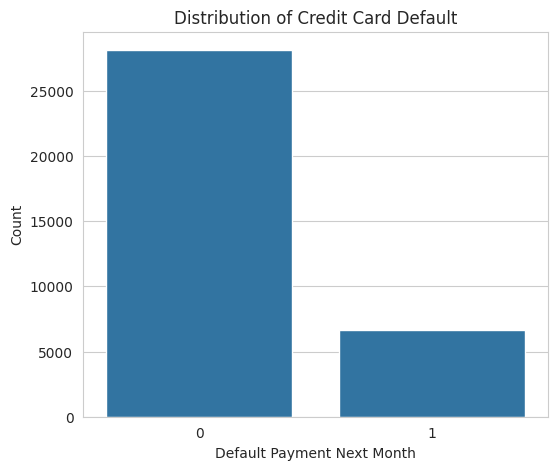

In [81]:
# Plot target variable distribution

plt.figure(figsize=(6,5))

sns.countplot(
    x='default.payment.next.month',
    data=df
)

plt.title('Distribution of Credit Card Default')
plt.xlabel('Default Payment Next Month')
plt.ylabel('Count')

plt.show()

# Descriptive Statistics for Important Numerical Features

In [82]:
# Select important numerical features

important_features = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM',
    'LIMIT_BAL_LOG',
    'risk_leak'
]

# Display descriptive statistics

df[important_features].describe()

,LIMIT_BAL,AGE,BILL_AMT_SUM,LIMIT_BAL_LOG,risk_leak
count,3.478800e+04,34788.000000,3.478800e+04,3.478800e+04,3.478800e+04
mean,1.824746e+05,35.441704,2.948152e+05,1.662693e+14,7.416380e+14
std,2.302661e+05,9.006903,5.718073e+05,2.347568e+14,2.614337e+15
min,1.000000e+04,21.000000,-3.362590e+05,1.030899e+13,-3.852082e+15
25%,6.000000e+04,28.000000,2.973825e+04,1.081980e+14,-4.113310e+14
50%,1.400000e+05,34.000000,1.290370e+05,1.191840e+14,1.039803e+14
75%,2.400000e+05,41.000000,3.502095e+05,1.250618e+14,7.814979e+14
max,5.600000e+06,79.000000,2.129266e+07,9.903538e+14,9.999707e+15


### Histograms for Numerical Features

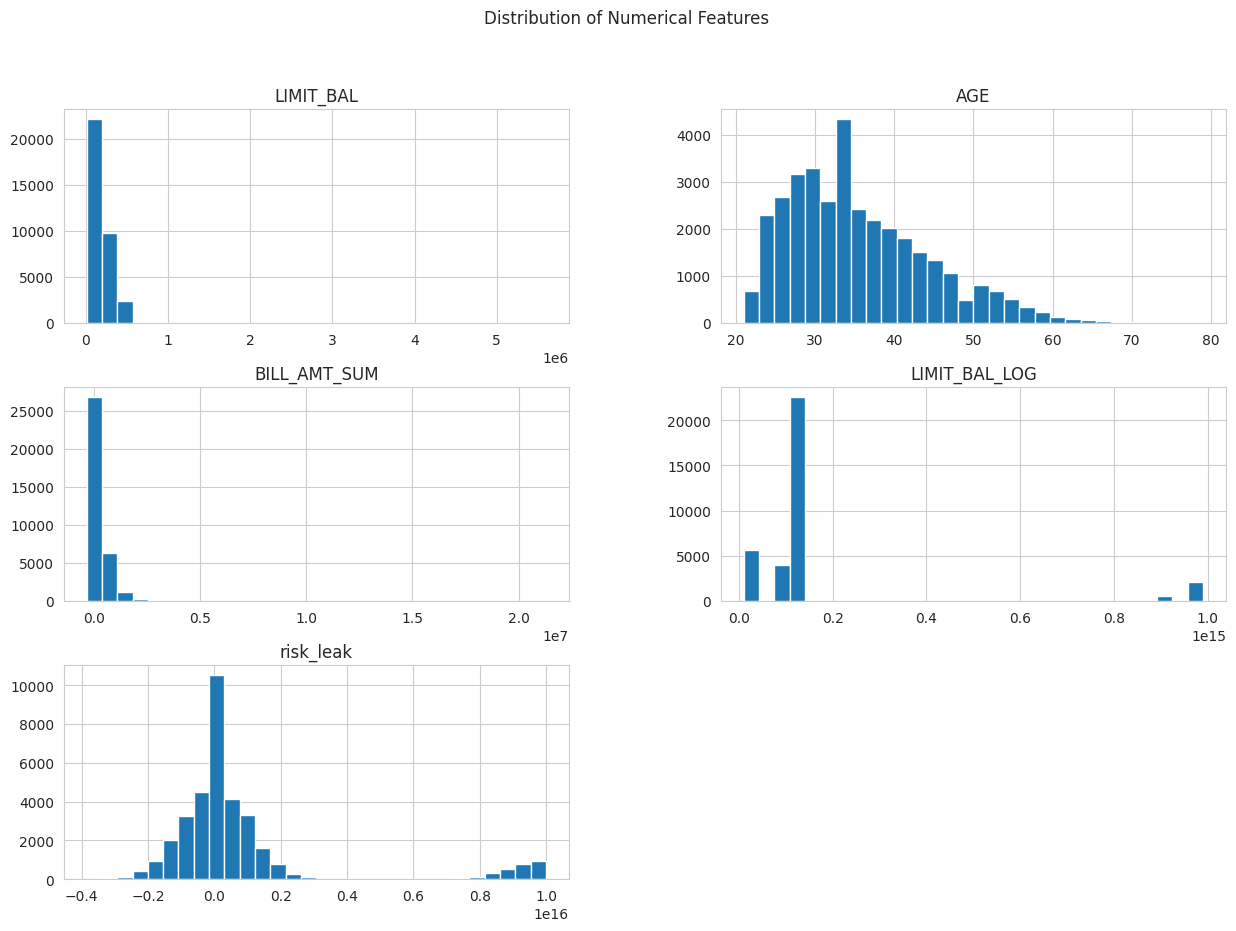

In [83]:
# Plot histograms for important numerical features

df[important_features].hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle('Distribution of Numerical Features')

plt.show()

### Boxplots for Numerical Features

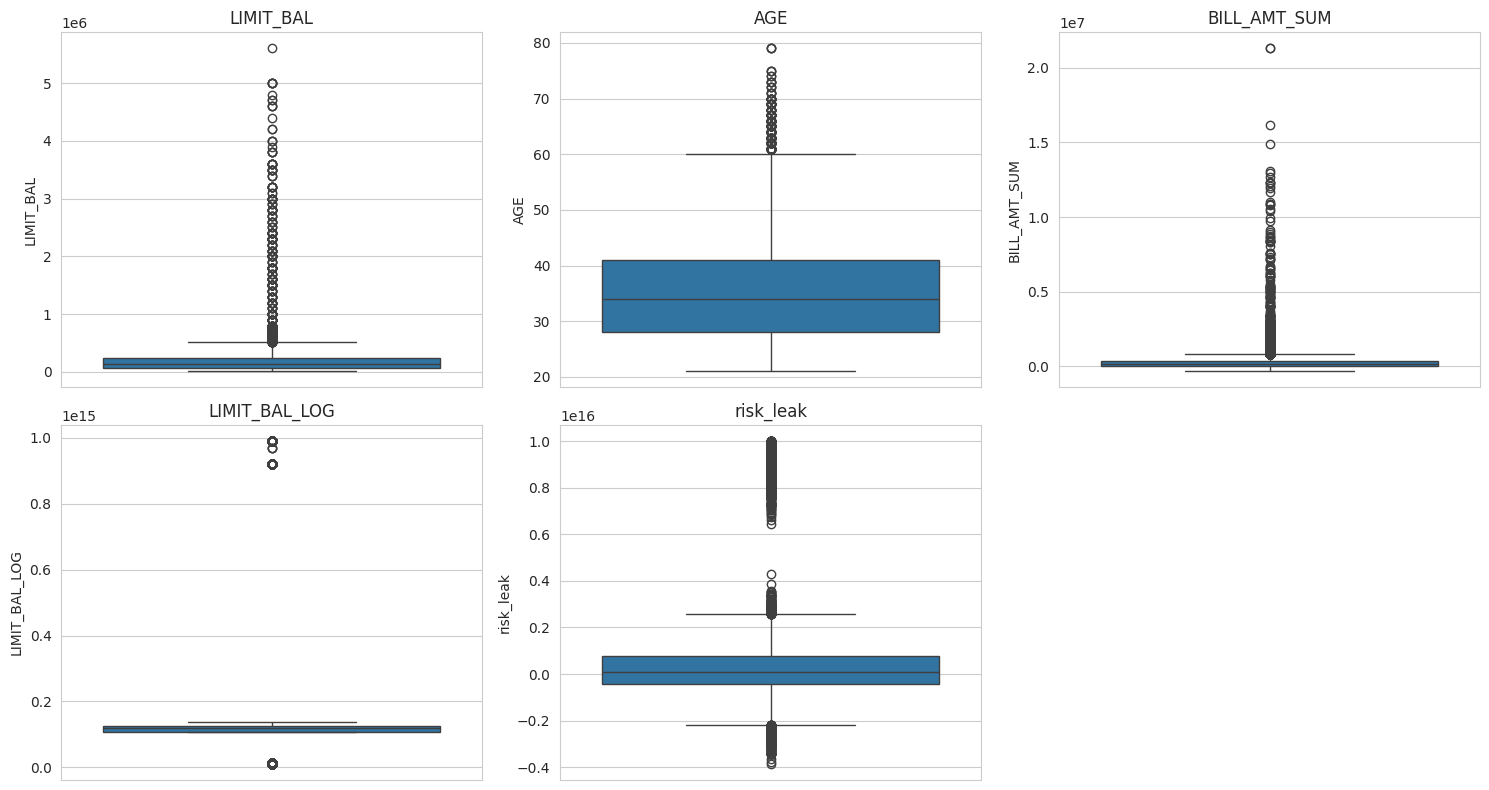

In [84]:
# Create boxplots for important numerical features

plt.figure(figsize=(15,8))

for i, col in enumerate(important_features, 1):
    
    plt.subplot(2,3,i)
    
    sns.boxplot(y=df[col])
    
    plt.title(col)

plt.tight_layout()

plt.show()

### Distribution of SEX

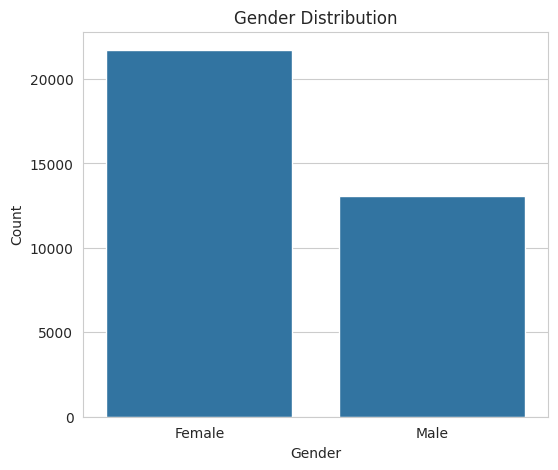

In [88]:
# Replace numeric values with labels

sex_labels = {
    1: 'Male',
    2: 'Female'
}

df['SEX_LABEL'] = df['SEX'].map(sex_labels)

# Plot gender distribution

plt.figure(figsize=(6,5))

sns.countplot(
    x='SEX_LABEL',
    data=df
)

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

### Distribution of EDUCATION

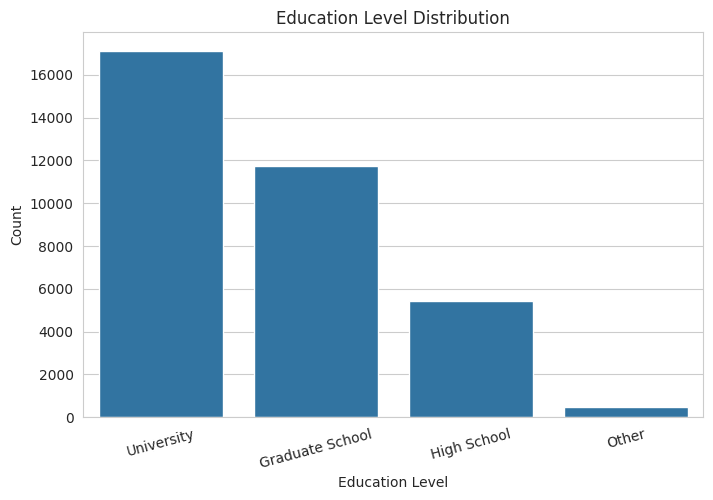

In [89]:
# Education labels

education_labels = {
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Other',
    5: 'Other',
    6: 'Other'
}

df['EDUCATION_LABEL'] = df['EDUCATION'].map(education_labels)

# Plot education distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='EDUCATION_LABEL',
    data=df,
    order=df['EDUCATION_LABEL'].value_counts().index
)

plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')

plt.xticks(rotation=15)

plt.show()

### Distribution of MARRIAGE

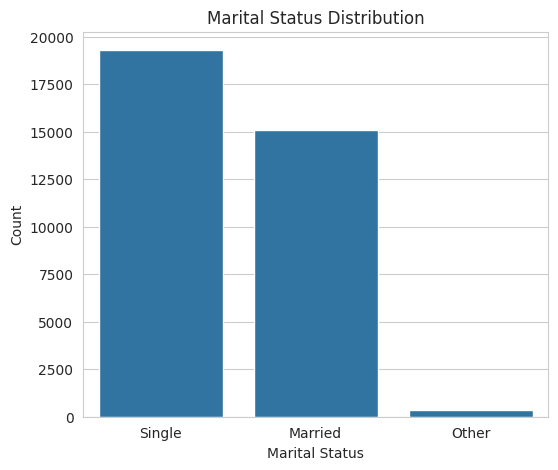

In [90]:
# Marriage labels

marriage_labels = {
    1: 'Married',
    2: 'Single',
    3: 'Other'
}

df['MARRIAGE_LABEL'] = df['MARRIAGE'].map(marriage_labels)

# Plot marital status distribution

plt.figure(figsize=(6,5))

sns.countplot(
    x='MARRIAGE_LABEL',
    data=df
)

plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')

plt.show()

### Distribution of CITY

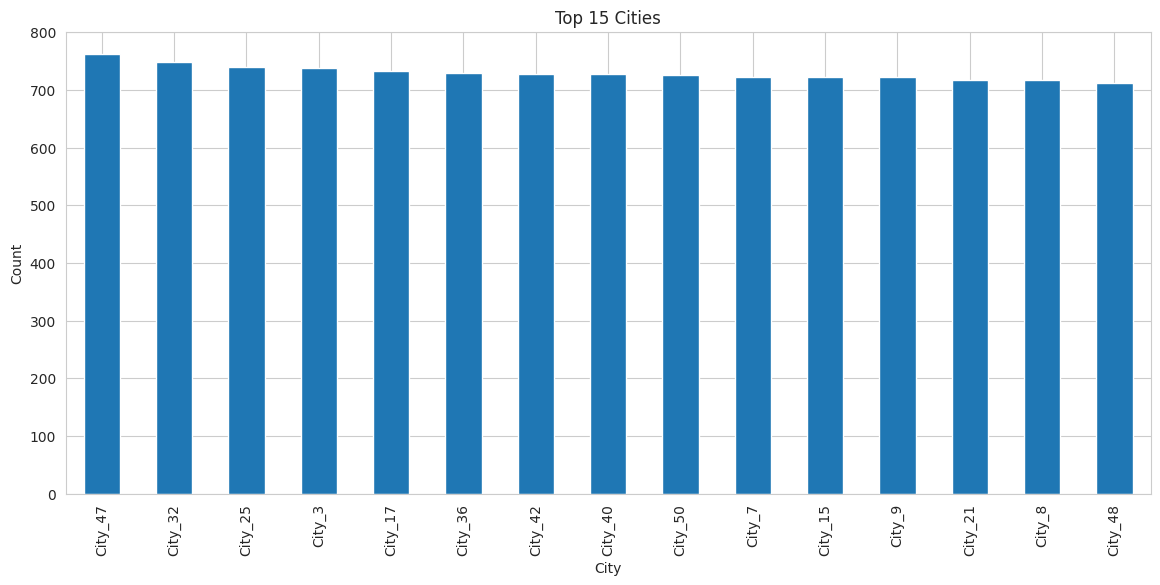

In [91]:
# Plot top 15 cities

plt.figure(figsize=(14,6))

df['CITY'].value_counts().head(15).plot(kind='bar')

plt.title('Top 15 Cities')

plt.xlabel('City')
plt.ylabel('Count')

plt.show()

### Distribution of RISK_RATING

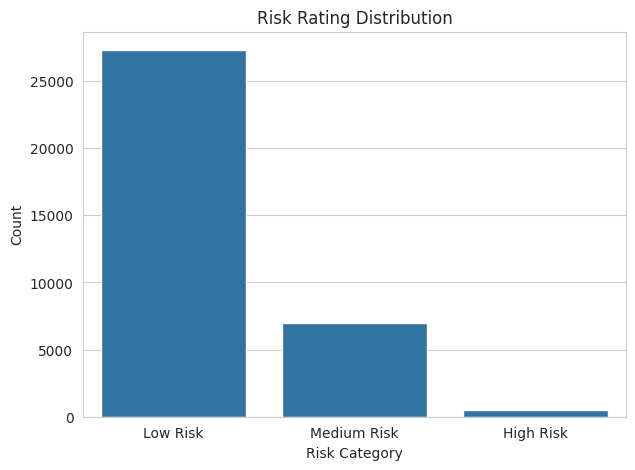

In [92]:
# Risk rating labels

risk_labels = {
    1: 'Low Risk',
    2: 'Medium Risk',
    3: 'High Risk'
}

df['RISK_LABEL'] = df['RISK_RATING'].map(risk_labels)

# Plot risk rating distribution

plt.figure(figsize=(7,5))

sns.countplot(
    x='RISK_LABEL',
    data=df,
    order=['Low Risk', 'Medium Risk', 'High Risk']
)

plt.title('Risk Rating Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Count')

plt.show()

### Payment History Analysis

In [93]:
# Payment status interpretation

payment_status_labels = {
    -2: 'No Consumption',
    -1: 'Paid in Full',
     0: 'Minimum Paid',
     1: '1 Month Delay',
     2: '2 Months Delay',
     3: '3 Months Delay',
     4: '4 Months Delay',
     5: '5 Months Delay',
     6: '6 Months Delay',
     7: '7 Months Delay',
     8: '8 Months Delay'
}

print(payment_status_labels)

{-2: 'No Consumption', -1: 'Paid in Full', 0: 'Minimum Paid', 1: '1 Month Delay', 2: '2 Months Delay', 3: '3 Months Delay', 4: '4 Months Delay', 5: '5 Months Delay', 6: '6 Months Delay', 7: '7 Months Delay', 8: '8 Months Delay'}


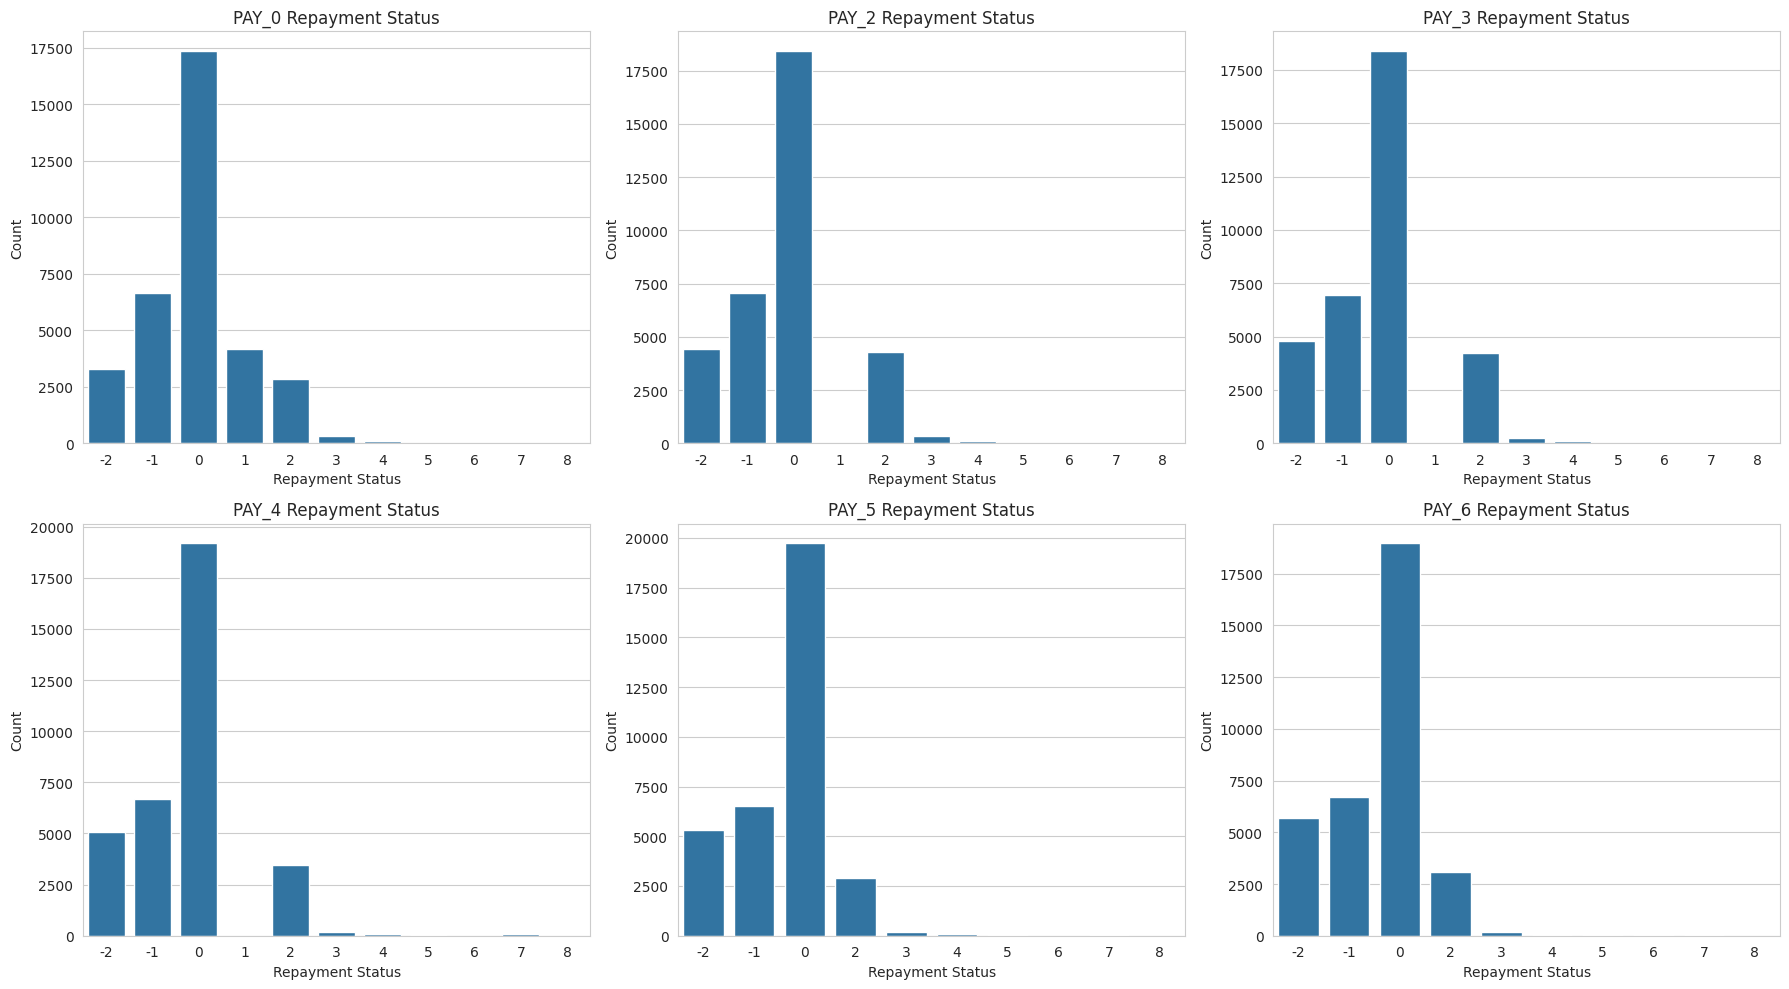

In [94]:
# Payment history columns

payment_history = [
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

# Plot payment history distributions

plt.figure(figsize=(18,10))

for i, col in enumerate(payment_history, 1):
    
    plt.subplot(2,3,i)
    
    sns.countplot(
        x=col,
        data=df,
        order=sorted(df[col].unique())
    )
    
    plt.title(f'{col} Repayment Status')
    plt.xlabel('Repayment Status')
    plt.ylabel('Count')

plt.tight_layout()

plt.show()

In [95]:
# Correlation matrix

correlation_matrix = df.corr(numeric_only=True)

# Display correlation matrix
correlation_matrix

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,RISK_RATING
ID,1.000000,0.012773,0.021762,0.034715,-0.024192,0.016260,-0.034856,-0.015506,-0.022850,-0.006976,-0.025535,-0.022960,0.015687,0.016143,0.021367,0.039122,0.014263,0.014684,0.010375,0.005424,0.039357,0.005520,0.002636,-0.000190,-0.012775,-0.007042,0.011773,-0.003421,-0.023751
LIMIT_BAL,0.012773,1.000000,0.018263,-0.129070,-0.055248,0.075402,-0.156443,-0.175331,-0.170583,-0.160203,-0.147930,-0.142012,0.161238,0.157591,0.162573,0.168510,0.168386,0.166701,0.105568,0.095782,0.112367,0.110272,0.121107,0.128489,-0.087402,-0.048494,0.456478,-0.173992,-0.088562
SEX,0.021762,0.018263,1.000000,0.009151,-0.030945,-0.082317,-0.058773,-0.071466,-0.066416,-0.060981,-0.056941,-0.045612,-0.032416,-0.029419,-0.023664,-0.020845,-0.016312,-0.014959,-0.000802,0.002220,-0.008361,-0.003126,-0.001110,-0.001972,-0.036321,-0.021245,-0.016005,-0.099292,-0.030205
EDUCATION,0.034715,-0.129070,0.009151,1.000000,-0.133262,0.166428,0.104651,0.118010,0.112324,0.106672,0.094660,0.082143,0.022429,0.018110,0.011595,-0.001367,-0.007251,-0.008509,-0.035835,-0.028243,-0.038660,-0.033110,-0.038416,-0.036326,0.027826,0.011729,0.001425,0.080035,0.036127
MARRIAGE,-0.024192,-0.055248,-0.030945,-0.133262,1.000000,-0.388346,0.020648,0.023693,0.032759,0.030459,0.034999,0.035030,-0.024510,-0.022219,-0.026633,-0.023553,-0.025308,-0.021475,-0.004419,-0.011527,-0.004275,-0.011746,-0.003700,-0.007451,-0.023085,-0.009691,-0.021315,0.067484,-0.012451
AGE,0.016260,0.075402,-0.082317,0.166428,-0.388346,1.000000,-0.040779,-0.051137,-0.054221,-0.051566,-0.056365,-0.051026,0.054897,0.052699,0.051444,0.051327,0.048160,0.045431,0.027062,0.017514,0.032009,0.017533,0.021180,0.016639,0.011351,0.003927,0.035463,-0.056087,-0.003390
PAY_0,-0.034856,-0.156443,-0.058773,0.104651,0.020648,-0.040779,1.000000,0.672901,0.573722,0.538412,0.508331,0.471332,0.191546,0.193127,0.180510,0.180054,0.181143,0.177051,-0.076578,-0.066144,-0.072204,-0.057918,-0.058527,-0.056985,0.314230,0.187346,0.141235,0.096338,0.791463
PAY_2,-0.015506,-0.175331,-0.071466,0.118010,0.023693,-0.051137,0.672901,1.000000,0.766480,0.663294,0.623838,0.573880,0.239399,0.239453,0.225401,0.224471,0.222530,0.220018,-0.074498,-0.056254,-0.056846,-0.045216,-0.036692,-0.034265,0.253757,0.151098,0.174084,0.120181,0.454534
PAY_3,-0.022850,-0.170583,-0.066416,0.112324,0.032759,-0.054221,0.573722,0.766480,1.000000,0.777626,0.685416,0.630938,0.213899,0.242347,0.229918,0.230397,0.226915,0.223882,0.003847,-0.060601,-0.052719,-0.045310,-0.034646,-0.035692,0.224862,0.129086,0.172328,0.119186,0.323920
PAY_4,-0.006976,-0.160203,-0.060981,0.106672,0.030459,-0.051566,0.538412,0.663294,0.777626,1.000000,0.816778,0.712745,0.210877,0.233480,0.250397,0.251927,0.247715,0.243783,-0.005886,-0.002857,-0.069088,-0.043258,-0.031509,-0.026196,0.207571,0.119477,0.179161,0.112558,0.287604


### Correlation Matrix

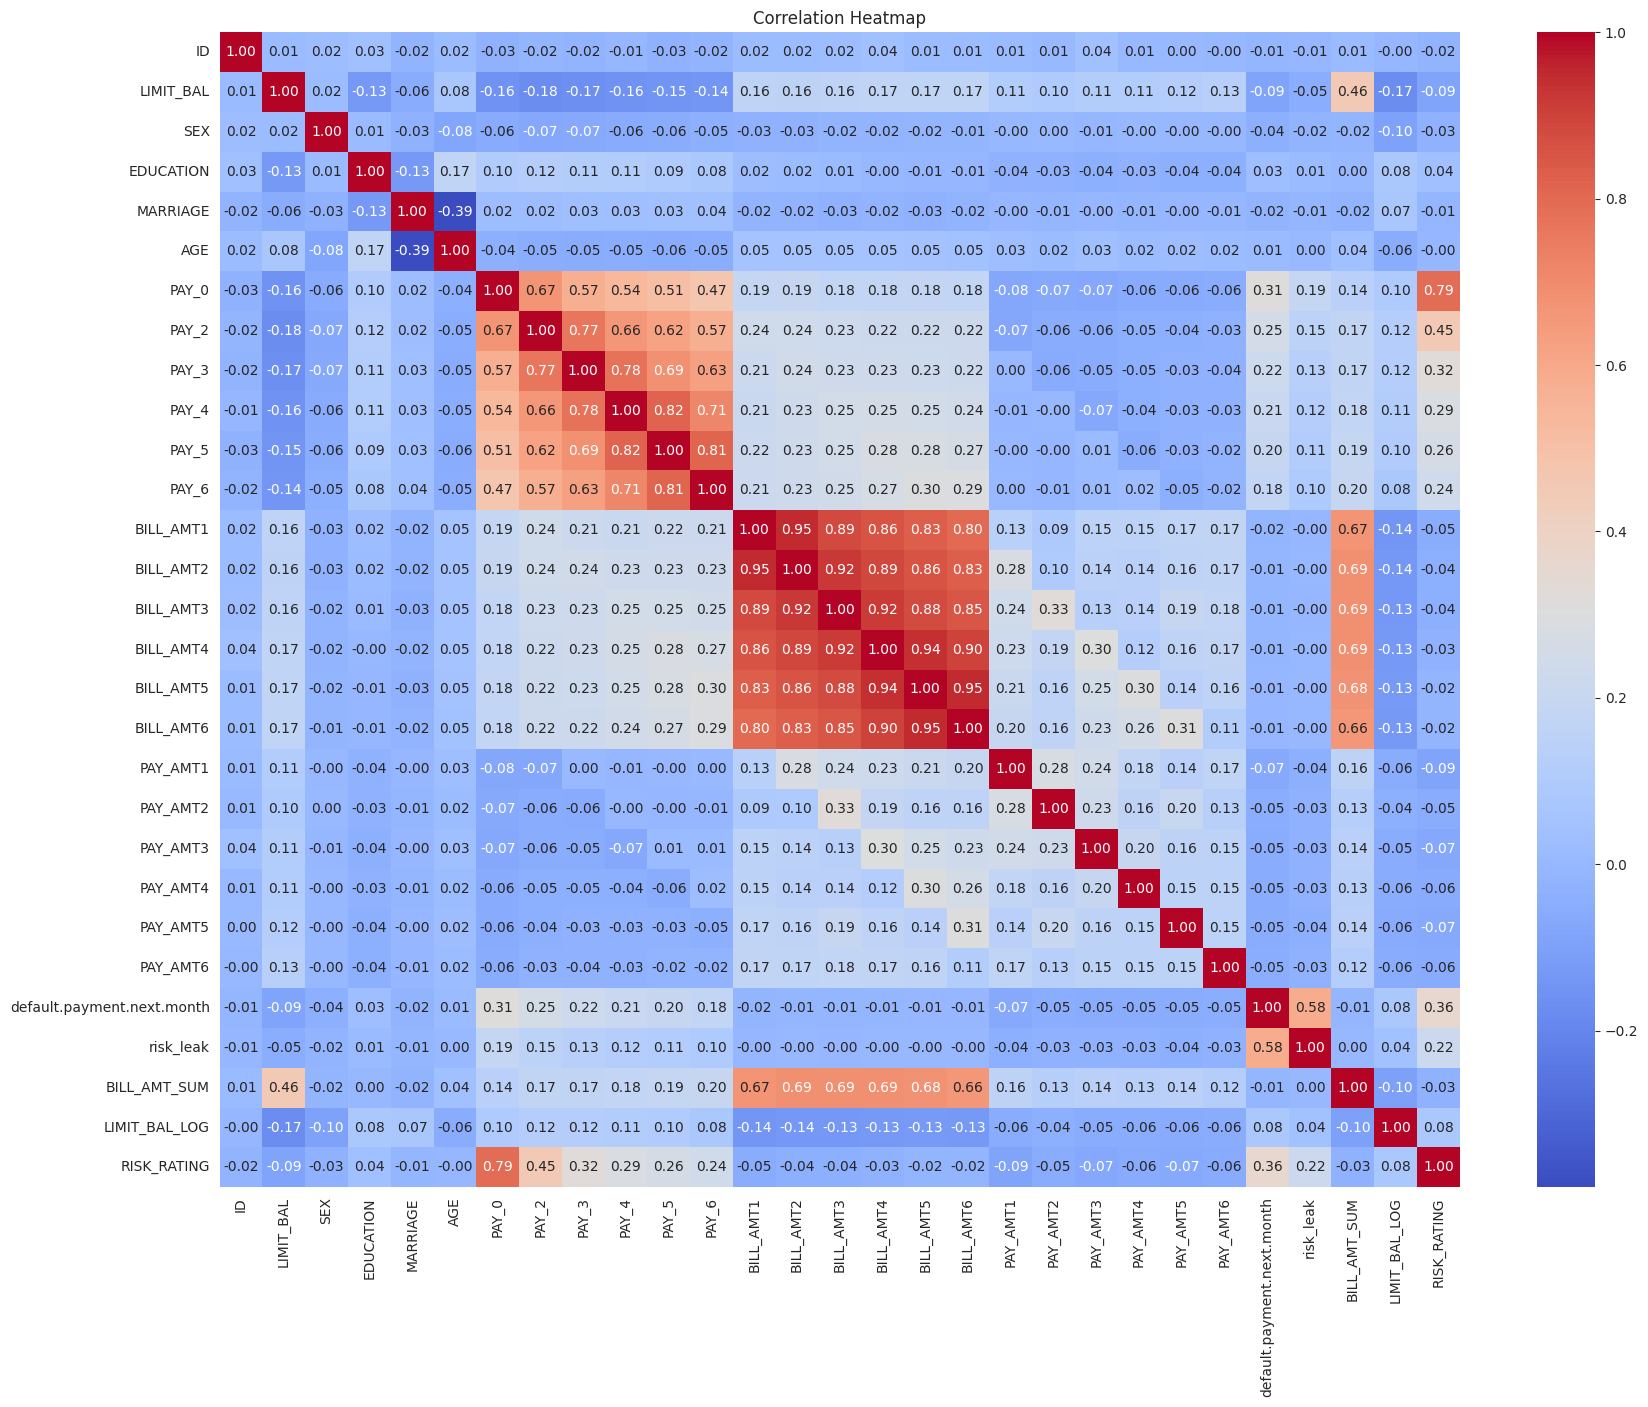

In [109]:
# Plot correlation heatmap

plt.figure(figsize=(20,15))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Correlation With Target Variable

In [97]:
# Correlation with target variable

target_correlation = correlation_matrix['default.payment.next.month'].sort_values(ascending=False)

print(target_correlation)

default.payment.next.month    1.000000
risk_leak                     0.584316
RISK_RATING                   0.362487
PAY_0                         0.314230
PAY_2                         0.253757
PAY_3                         0.224862
PAY_4                         0.207571
PAY_5                         0.196277
PAY_6                         0.179303
LIMIT_BAL_LOG                 0.083327
EDUCATION                     0.027826
AGE                           0.011351
BILL_AMT6                    -0.005909
BILL_AMT5                    -0.007094
BILL_AMT4                    -0.009931
BILL_AMT_SUM                 -0.010079
ID                           -0.012775
BILL_AMT3                    -0.013771
BILL_AMT2                    -0.014030
BILL_AMT1                    -0.018940
MARRIAGE                     -0.023085
SEX                          -0.036321
PAY_AMT6                     -0.049474
PAY_AMT2                     -0.050151
PAY_AMT5                     -0.052321
PAY_AMT4                 

### Top Features Correlated With Default

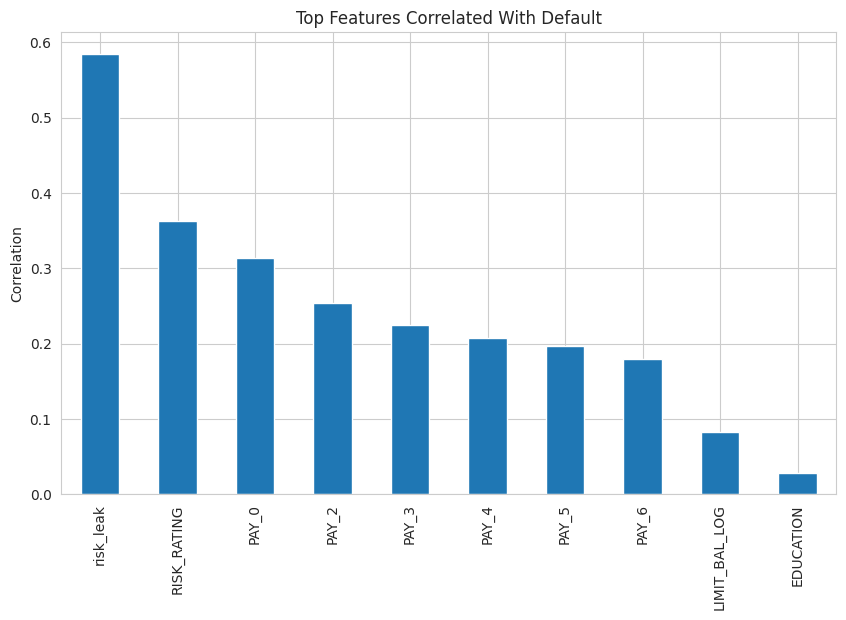

In [98]:
# Plot top correlated features with target

top_corr = target_correlation[1:11]

plt.figure(figsize=(10,6))

top_corr.plot(kind='bar')

plt.title('Top Features Correlated With Default')

plt.ylabel('Correlation')

plt.show()

### Analyze Default Rate by Risk Rating

In [99]:
# Default rate by risk category

risk_default = df.groupby('RISK_LABEL')['default.payment.next.month'].mean()

print(risk_default)

RISK_LABEL
High Risk      0.680982
Low Risk       0.117852
Medium Risk    0.443588
Name: default.payment.next.month, dtype: float64


### Visualize Default Rate by Risk Rating

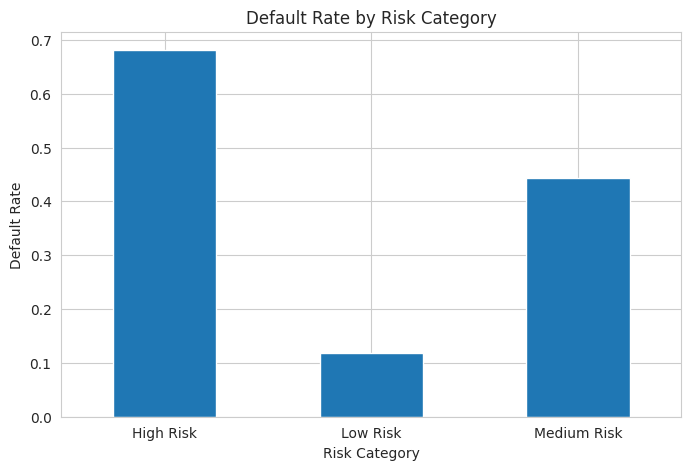

In [100]:
# Plot default rate by risk category

risk_default.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Default Rate by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Default Rate')

plt.xticks(rotation=0)

plt.show()

In [101]:
# Default rate by gender

gender_default = df.groupby('SEX_LABEL')['default.payment.next.month'].mean()

print(gender_default)

SEX_LABEL
Female    0.180249
Male      0.209749
Name: default.payment.next.month, dtype: float64


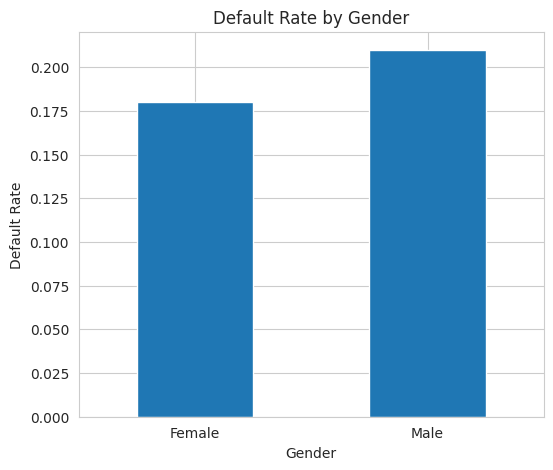

In [102]:
# Plot default rate by gender

gender_default.plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Default Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Default Rate')

plt.xticks(rotation=0)

plt.show()

### Analyze Default Rate by PAY_0

In [104]:
# Default rate by PAY_0

pay0_default = df.groupby('PAY_0')['default.payment.next.month'].mean()

print(pay0_default)

PAY_0
-2    0.112267
-1    0.143586
 0    0.109025
 1    0.302303
 2    0.651376
 3    0.719764
 4    0.650000
 5    0.433333
 6    0.500000
 7    0.777778
 8    0.578947
Name: default.payment.next.month, dtype: float64


### Visualize Default Rate by PAY_0

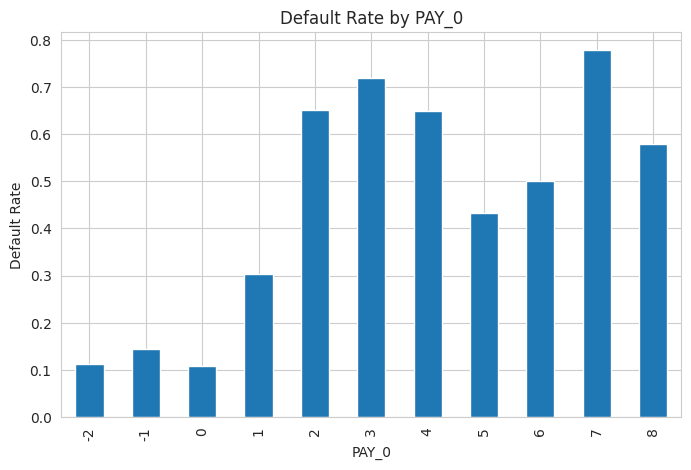

In [105]:
# Plot default rate by PAY_0

pay0_default.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Default Rate by PAY_0')

plt.ylabel('Default Rate')

plt.show()

### Pairplot for Important Features

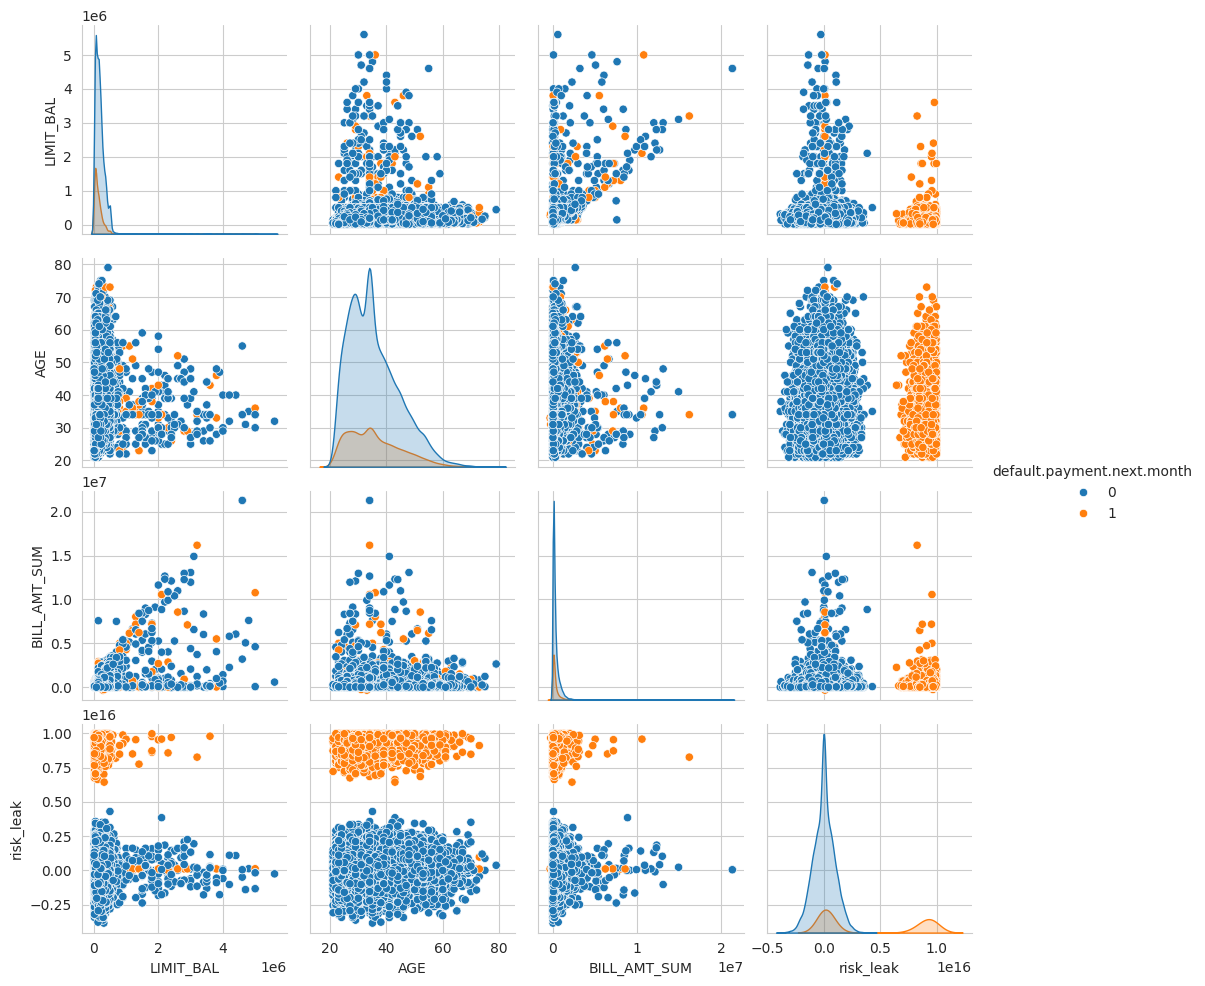

In [106]:
# Pairplot for selected features

selected_features = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM',
    'risk_leak',
    'default.payment.next.month'
]

sns.pairplot(
    df[selected_features],
    hue='default.payment.next.month'
)

plt.show()

In [107]:
# Display class imbalance percentage

class_distribution = df['default.payment.next.month'].value_counts(normalize=True) * 100

print(class_distribution)

default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


# DATA PREPROCESSING (TASK 2)

In [110]:
# Drop ID column

df.drop('ID', axis=1, inplace=True)

In [111]:
# Display first 5 rows

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,RISK_LABEL
0,20000.0,2.0,2.0,2.0,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075675e+14,7704.0,9.903538e+14,City_38,2,Female,University,Single,Medium Risk
1,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,1.094084e+14,17077.0,1.169526e+14,City_6,1,Female,University,Single,Low Risk
2,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,7.030225e+14,101653.0,1.140758e+14,City_20,1,Female,University,Single,Low Risk
3,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,5.844244e+14,231334.0,1.081980e+14,City_25,1,Female,University,Married,Low Risk
4,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,1.294310e+14,109339.0,1.081980e+14,City_44,1,Male,University,Married,Low Risk


### Encode CITY Column

In [112]:
# Apply label encoding to CITY column

from sklearn.preprocessing import LabelEncoder

city_encoder = LabelEncoder()

df['CITY'] = city_encoder.fit_transform(df['CITY'])

In [113]:
# Display CITY values after encoding

df['CITY'].head()

0    31
1    46
2    12
3    17
4    38
Name: CITY, dtype: int64

In [114]:
# Drop temporary label columns

df.drop([
    'SEX_LABEL',
    'EDUCATION_LABEL',
    'MARRIAGE_LABEL',
    'RISK_LABEL'
], axis=1, inplace=True)

In [115]:
# Display all columns

print(df.columns)

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM',
       'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING'],
      dtype='object')


In [116]:
# Separate independent and dependent variables

X = df.drop('default.payment.next.month', axis=1)

y = df['default.payment.next.month']

In [117]:
# Display shapes

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (34788, 28)
Target Shape: (34788,)


### Train-Test Split

In [118]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [119]:
# Display train and test shapes

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (27830, 28)
X_test Shape: (6958, 28)
y_train Shape: (27830,)
y_test Shape: (6958,)


### Apply Feature Scaling

In [120]:
# Apply StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [121]:
# Convert scaled arrays back to DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

In [122]:
# Display scaled training data

X_train_scaled.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,0.994001,0.774166,-1.110895,-1.109580,0.289063,1.850000,1.832978,1.858103,0.209396,0.260243,0.275416,1.754222,1.892379,1.865262,2.046545,2.060419,1.265463,0.132214,-0.249254,0.014288,0.036050,-0.019805,-0.004679,3.026872,1.234463,-0.158936,-1.492487,1.700305
1,-0.581565,-1.291712,0.182021,0.822206,-0.045275,0.040253,0.135132,0.160043,0.209396,0.260243,0.275416,-0.019818,-0.036545,0.014591,0.089865,-0.236342,-0.212931,1.132904,-0.155654,-0.176171,-0.246973,-0.250292,-0.238062,3.424651,-0.086673,-0.248493,-1.700309,-0.507378
2,-0.406502,0.774166,0.182021,0.822206,-0.268167,0.040253,0.135132,-0.688986,-0.664030,0.260243,0.275416,0.164989,-0.666778,-0.649483,0.195488,0.314958,0.022260,-0.281587,-0.164171,3.109818,0.008463,-0.198292,-0.226925,3.391694,-0.127186,-0.223476,1.347751,-0.507378
3,-0.669097,-1.291712,0.182021,-1.109580,-0.602505,0.040253,0.135132,0.160043,0.209396,0.260243,-0.613568,-0.301419,-0.261318,-0.256112,-0.307523,-0.312700,-0.173180,-0.219486,0.177313,-0.228155,-0.244930,1.544269,-0.223082,-0.092847,-0.233501,-0.665136,0.447188,-0.507378
4,-0.581565,0.774166,0.182021,0.822206,-0.491059,0.040253,0.135132,0.160043,0.209396,0.260243,0.275416,-0.075707,-0.023262,0.013915,-0.545304,-0.531776,-0.493651,-0.114888,-0.036418,-0.240384,-0.291100,-0.185293,-0.238062,-0.044770,-0.225395,-0.248493,-1.561761,-0.507378


In [125]:
# Final dataset check

print("Training Features Shape:", X_train_scaled.shape)
print("Testing Features Shape:", X_test_scaled.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (27830, 28)
Testing Features Shape: (6958, 28)
Training Labels Shape: (27830,)
Testing Labels Shape: (6958,)


# MODEL TRAINING (TASK 3)

### Train Logistic Regression Model

In [134]:
logistic_model = LogisticRegression()

# Train Logistic Regression

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [135]:
# Logistic Regression predictions

y_pred_logistic = logistic_model.predict(X_test_scaled)

y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:,1]

### Train Decision Tree

In [136]:
decision_tree_model = DecisionTreeClassifier()


# Train Decision Tree

decision_tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [137]:
# Decision Tree predictions

y_pred_decision_tree = decision_tree_model.predict(X_test_scaled)

y_prob_decision_tree = decision_tree_model.predict_proba(X_test_scaled)[:,1]

### Train Random Forest

In [138]:
random_forest_model = RandomForestClassifier()


# Train Random Forest

random_forest_model.fit(X_train_scaled, y_train)

RandomForestClassifier()

In [139]:
# Random Forest predictions

y_pred_random_forest = random_forest_model.predict(X_test_scaled)

y_prob_random_forest = random_forest_model.predict_proba(X_test_scaled)[:,1]

### Train KNN Model

In [140]:
knn_model = KNeighborsClassifier()

# Train KNN

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [141]:
# KNN predictions

y_pred_knn = knn_model.predict(X_test_scaled)

y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

### Train Support Vector Machine

In [142]:
svm_model = SVC(probability=True)

# Train Support Vector Machine

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True)

In [143]:
# SVM predictions

y_pred_svm = svm_model.predict(X_test_scaled)

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

In [144]:
# Display default hyperparameters

print("Logistic Regression Parameters:\n")
print(logistic_model.get_params())

print("\nDecision Tree Parameters:\n")
print(decision_tree_model.get_params())

print("\nRandom Forest Parameters:\n")
print(random_forest_model.get_params())

print("\nKNN Parameters:\n")
print(knn_model.get_params())

print("\nSVM Parameters:\n")
print(svm_model.get_params())

Logistic Regression Parameters:

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Decision Tree Parameters:

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}

Random Forest Parameters:

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_

In [145]:
# Display prediction shapes

print("Logistic Regression:", y_pred_logistic.shape)

print("Decision Tree:", y_pred_decision_tree.shape)

print("Random Forest:", y_pred_random_forest.shape)

print("KNN:", y_pred_knn.shape)

print("SVM:", y_pred_svm.shape)

Logistic Regression: (6958,)
Decision Tree: (6958,)
Random Forest: (6958,)
KNN: (6958,)
SVM: (6958,)


# MODEL EVALUATION (TASK 4)

In [146]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [147]:
# Create empty list to store model results

model_results = []

In [156]:
# Function to plot confusion matrix

def plot_confusion_matrix(y_true, y_pred, title):
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5,4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    plt.show()

In [148]:
# Logistic Regression evaluation

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

logistic_precision = precision_score(y_test, y_pred_logistic)

logistic_recall = recall_score(y_test, y_pred_logistic)

logistic_f1 = f1_score(y_test, y_pred_logistic)

logistic_auc = roc_auc_score(y_test, y_prob_logistic)

# Store results

model_results.append([
    'Logistic Regression',
    logistic_accuracy,
    logistic_precision,
    logistic_recall,
    logistic_f1,
    logistic_auc
])

# Print classification report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      5627
           1       0.85      0.46      0.60      1331

    accuracy                           0.88      6958
   macro avg       0.87      0.72      0.76      6958
weighted avg       0.88      0.88      0.87      6958



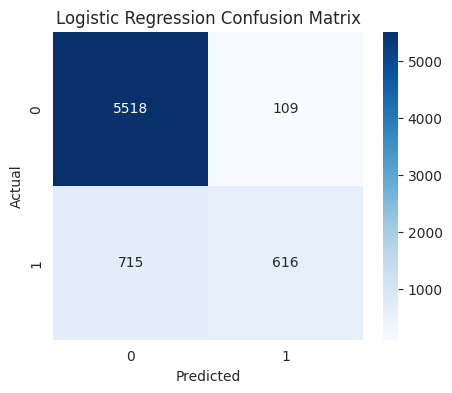

In [157]:
# Logistic Regression confusion matrix

plot_confusion_matrix(
    y_test,
    y_pred_logistic,
    'Logistic Regression Confusion Matrix'
)

In [149]:
# Decision Tree evaluation

decision_tree_accuracy = accuracy_score(y_test, y_pred_decision_tree)

decision_tree_precision = precision_score(y_test, y_pred_decision_tree)

decision_tree_recall = recall_score(y_test, y_pred_decision_tree)

decision_tree_f1 = f1_score(y_test, y_pred_decision_tree)

decision_tree_auc = roc_auc_score(y_test, y_prob_decision_tree)

# Store results

model_results.append([
    'Decision Tree',
    decision_tree_accuracy,
    decision_tree_precision,
    decision_tree_recall,
    decision_tree_f1,
    decision_tree_auc
])

# Print classification report

print(classification_report(y_test, y_pred_decision_tree))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5627
           1       0.96      0.89      0.92      1331

    accuracy                           0.97      6958
   macro avg       0.97      0.94      0.95      6958
weighted avg       0.97      0.97      0.97      6958



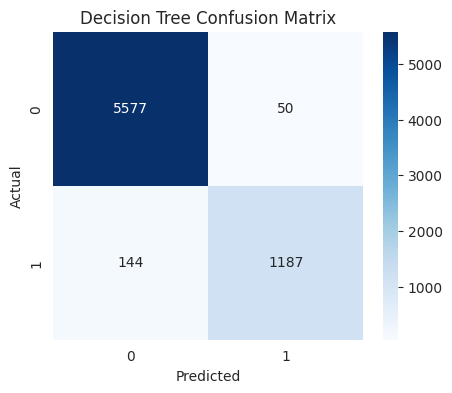

In [158]:
# Decision Tree confusion matrix

plot_confusion_matrix(
    y_test,
    y_pred_decision_tree,
    'Decision Tree Confusion Matrix'
)

In [150]:
# Random Forest evaluation

random_forest_accuracy = accuracy_score(y_test, y_pred_random_forest)

random_forest_precision = precision_score(y_test, y_pred_random_forest)

random_forest_recall = recall_score(y_test, y_pred_random_forest)

random_forest_f1 = f1_score(y_test, y_pred_random_forest)

random_forest_auc = roc_auc_score(y_test, y_prob_random_forest)

# Store results

model_results.append([
    'Random Forest',
    random_forest_accuracy,
    random_forest_precision,
    random_forest_recall,
    random_forest_f1,
    random_forest_auc
])

# Print classification report

print(classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5627
           1       0.98      0.78      0.87      1331

    accuracy                           0.95      6958
   macro avg       0.96      0.89      0.92      6958
weighted avg       0.96      0.95      0.95      6958



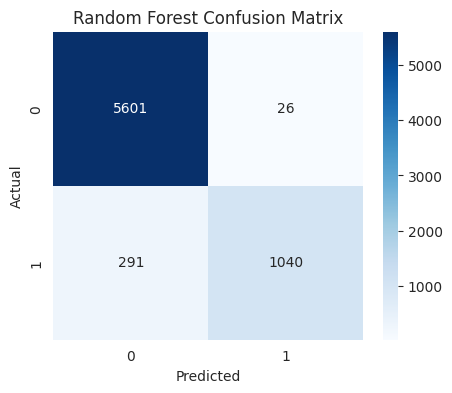

In [159]:
# Random Forest confusion matrix

plot_confusion_matrix(
    y_test,
    y_pred_random_forest,
    'Random Forest Confusion Matrix'
)

In [151]:
# KNN evaluation

knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(y_test, y_pred_knn)

knn_recall = recall_score(y_test, y_pred_knn)

knn_f1 = f1_score(y_test, y_pred_knn)

knn_auc = roc_auc_score(y_test, y_prob_knn)

# Store results

model_results.append([
    'K-Nearest Neighbors',
    knn_accuracy,
    knn_precision,
    knn_recall,
    knn_f1,
    knn_auc
])

# Print classification report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94      5627
           1       0.83      0.54      0.65      1331

    accuracy                           0.89      6958
   macro avg       0.86      0.76      0.79      6958
weighted avg       0.89      0.89      0.88      6958



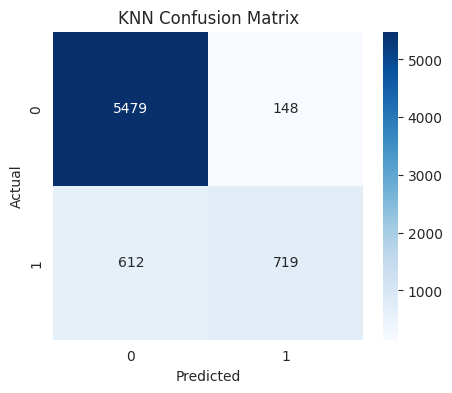

In [160]:
# KNN confusion matrix

plot_confusion_matrix(
    y_test,
    y_pred_knn,
    'KNN Confusion Matrix'
)

In [152]:
# SVM evaluation

svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(y_test, y_pred_svm)

svm_recall = recall_score(y_test, y_pred_svm)

svm_f1 = f1_score(y_test, y_pred_svm)

svm_auc = roc_auc_score(y_test, y_prob_svm)

# Store results

model_results.append([
    'Support Vector Machine',
    svm_accuracy,
    svm_precision,
    svm_recall,
    svm_f1,
    svm_auc
])

# Print classification report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      5627
           1       0.89      0.51      0.65      1331

    accuracy                           0.89      6958
   macro avg       0.89      0.75      0.79      6958
weighted avg       0.89      0.89      0.88      6958



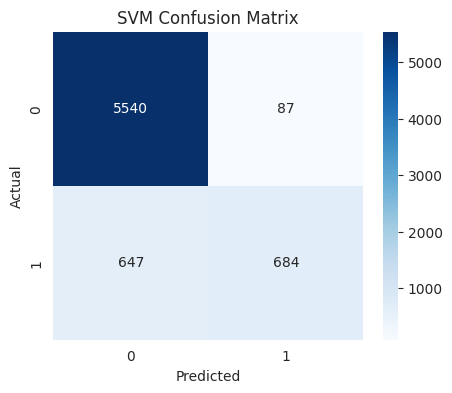

In [161]:
# SVM confusion matrix

plot_confusion_matrix(
    y_test,
    y_pred_svm,
    'SVM Confusion Matrix'
)

In [153]:
# Create results dataframe

results_df = pd.DataFrame(
    model_results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ]
)

# Display results table

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.881575,0.849655,0.462810,0.599222,0.856622
1,Decision Tree,0.972118,0.959580,0.891811,0.924455,0.941462
2,Random Forest,0.954441,0.975610,0.781367,0.867751,0.991007
3,K-Nearest Neighbors,0.890773,0.829296,0.540195,0.654231,0.829553
4,Support Vector Machine,0.894510,0.887160,0.513899,0.650809,0.809741


In [154]:
# Sort results by ROC-AUC

results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.954441,0.975610,0.781367,0.867751,0.991007
1,Decision Tree,0.972118,0.959580,0.891811,0.924455,0.941462
0,Logistic Regression,0.881575,0.849655,0.462810,0.599222,0.856622
3,K-Nearest Neighbors,0.890773,0.829296,0.540195,0.654231,0.829553
4,Support Vector Machine,0.894510,0.887160,0.513899,0.650809,0.809741


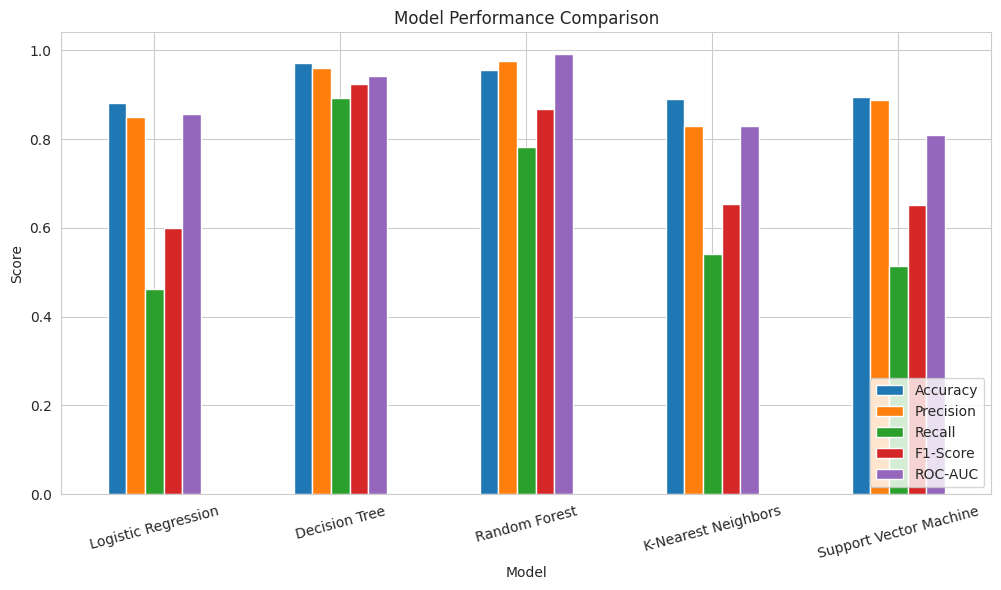

In [155]:
# Plot model comparison

results_df.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Model Performance Comparison')

plt.ylabel('Score')

plt.xticks(rotation=15)

plt.legend(loc='lower right')

plt.show()

In [162]:
# Function to plot ROC curve

def plot_roc_curve(y_true, y_prob, model_name):
    
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    
    auc_score = roc_auc_score(y_true, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc_score:.3f})'
    )

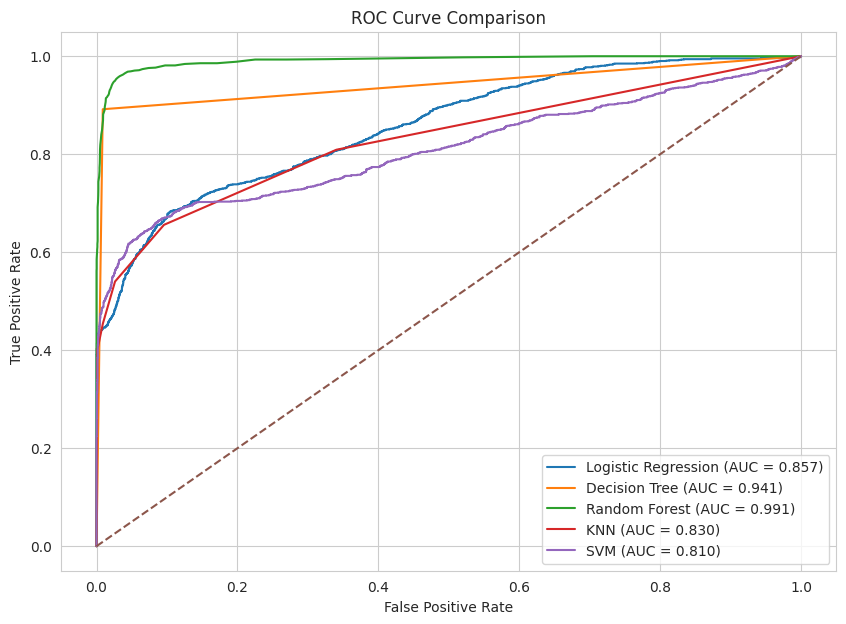

In [163]:
# Plot ROC curves

plt.figure(figsize=(10,7))

# Logistic Regression
plot_roc_curve(
    y_test,
    y_prob_logistic,
    'Logistic Regression'
)

# Decision Tree
plot_roc_curve(
    y_test,
    y_prob_decision_tree,
    'Decision Tree'
)

# Random Forest
plot_roc_curve(
    y_test,
    y_prob_random_forest,
    'Random Forest'
)

# KNN
plot_roc_curve(
    y_test,
    y_prob_knn,
    'KNN'
)

# SVM
plot_roc_curve(
    y_test,
    y_prob_svm,
    'SVM'
)

# Random prediction line
plt.plot([0,1], [0,1], linestyle='--')

plt.title('ROC Curve Comparison')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

In [164]:
# Identify best model based on ROC-AUC

best_model = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
).iloc[0]

print(best_model)

Model        Random Forest
Accuracy          0.954441
Precision          0.97561
Recall            0.781367
F1-Score          0.867751
ROC-AUC           0.991007
Name: 2, dtype: object


# HYPERPARAMETER TUNING

In [181]:
# Define hyperparameter grid

param_grid = {
    
    'n_estimators': [100, 200, 300],
    
    'max_depth': [None, 10, 20],
    
    'min_samples_split': [2, 5, 10],
    
    'min_samples_leaf': [1, 2, 4]
}

In [182]:
# Initialize GridSearchCV

grid_search = GridSearchCV(
    
    estimator=RandomForestClassifier(random_state=42),
    
    param_grid=param_grid,
    
    cv=3,
    
    scoring='roc_auc',
    
    n_jobs=-1,
    
    verbose=1
)

# Train GridSearchCV

grid_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 81 candidates, totalling 243 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=1)

In [184]:
# Display best parameters

print("Best Parameters:\n")

print(grid_search.best_params_)

Best Parameters:

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [185]:
# Display best ROC-AUC score

print("Best ROC-AUC Score:\n")

print(grid_search.best_score_)

Best ROC-AUC Score:

0.9816005223407291


In [186]:
# Extract best model

best_random_forest = grid_search.best_estimator_

In [187]:
# Predictions using tuned model

y_pred_tuned = best_random_forest.predict(X_test_scaled)

y_prob_tuned = best_random_forest.predict_proba(X_test_scaled)[:,1]

In [188]:
# Evaluate tuned Random Forest

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

tuned_precision = precision_score(y_test, y_pred_tuned)

tuned_recall = recall_score(y_test, y_pred_tuned)

tuned_f1 = f1_score(y_test, y_pred_tuned)

tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print("Accuracy:", tuned_accuracy)

print("Precision:", tuned_precision)

print("Recall:", tuned_recall)

print("F1-Score:", tuned_f1)

print("ROC-AUC:", tuned_auc)

Accuracy: 0.9573153204943949
Precision: 0.9734432234432234
Recall: 0.7986476333583772
F1-Score: 0.8774246801485761
ROC-AUC: 0.9912361071185043


In [189]:
# Classification report

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5627
           1       0.97      0.80      0.88      1331

    accuracy                           0.96      6958
   macro avg       0.96      0.90      0.93      6958
weighted avg       0.96      0.96      0.96      6958



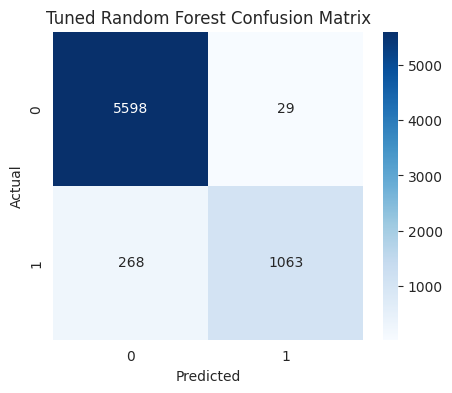

In [190]:
# Confusion matrix for tuned model

plot_confusion_matrix(
    y_test,
    y_pred_tuned,
    'Tuned Random Forest Confusion Matrix'
)

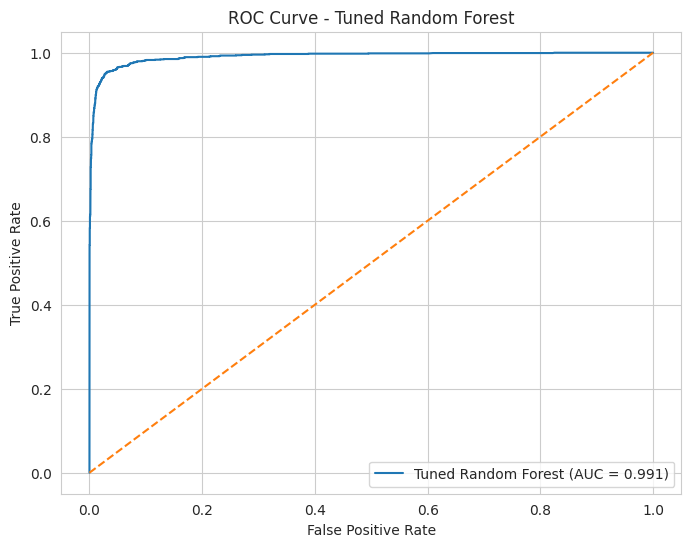

In [191]:
# ROC curve for tuned Random Forest

plt.figure(figsize=(8,6))

plot_roc_curve(
    y_test,
    y_prob_tuned,
    'Tuned Random Forest'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.title('ROC Curve - Tuned Random Forest')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

In [192]:
# Compare model performance before and after tuning

comparison_df = pd.DataFrame({
    
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ],
    
    'Before Tuning': [
        random_forest_accuracy,
        random_forest_precision,
        random_forest_recall,
        random_forest_f1,
        random_forest_auc
    ],
    
    'After Tuning': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_auc
    ]
})

comparison_df

,Metric,Before Tuning,After Tuning
0,Accuracy,0.954441,0.957315
1,Precision,0.975610,0.973443
2,Recall,0.781367,0.798648
3,F1-Score,0.867751,0.877425
4,ROC-AUC,0.991007,0.991236


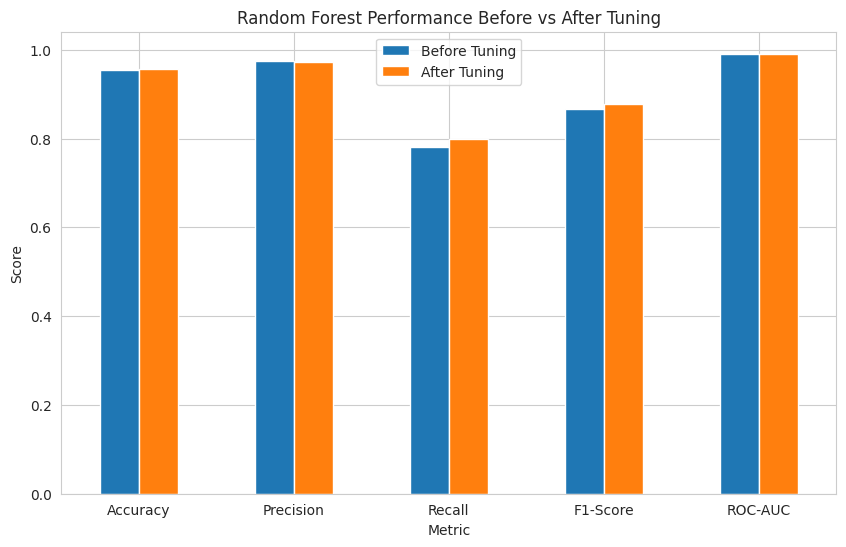

In [193]:
# Plot performance comparison

comparison_df.set_index('Metric').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Random Forest Performance Before vs After Tuning')

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.legend()

plt.show()

# EXPLAINABLE AI

In [194]:
# Import SHAP

import shap

In [195]:
# Initialize SHAP TreeExplainer

explainer = shap.TreeExplainer(random_forest_model)

In [196]:
# Generate SHAP values

shap_values = explainer.shap_values(X_test_scaled)

In [197]:
# Display SHAP value shape

print(np.array(shap_values).shape)

(6958, 28, 2)


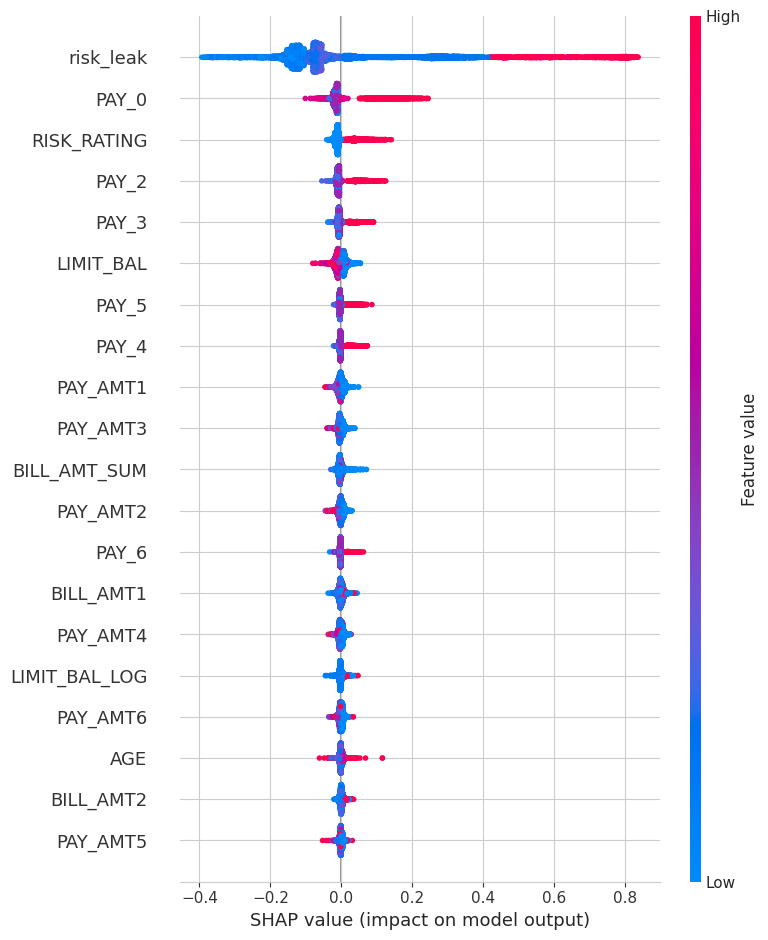

In [198]:
# SHAP summary plot

shap.summary_plot(
    shap_values[:,:,1],
    X_test_scaled
)

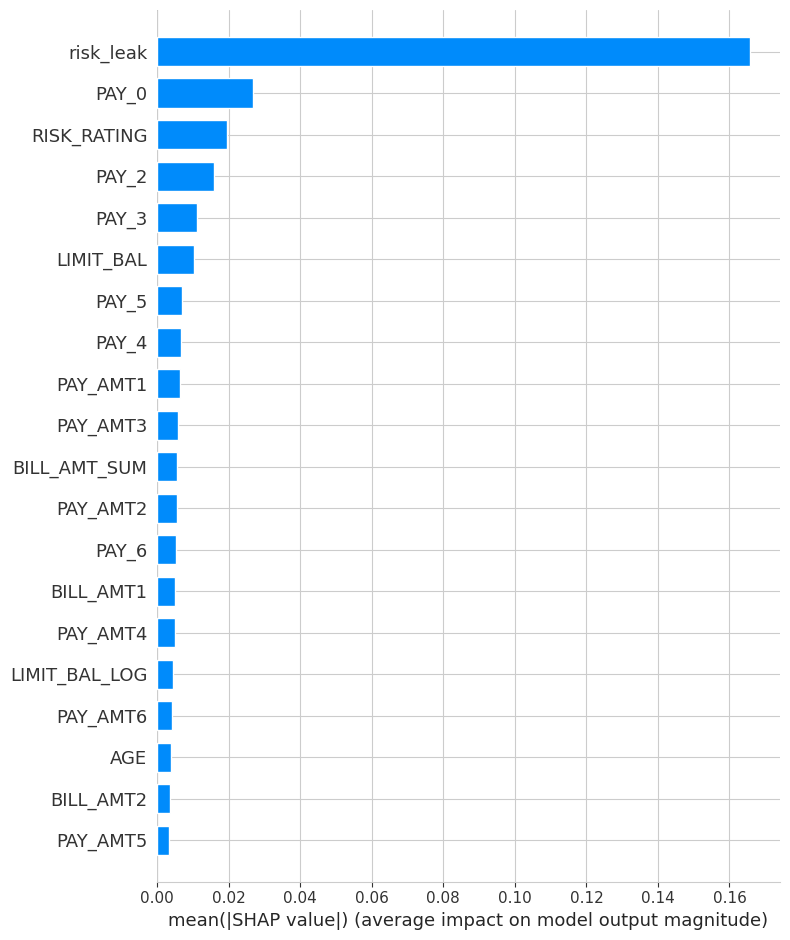

In [199]:
# SHAP feature importance bar plot

shap.summary_plot(
    shap_values[:,:,1],
    X_test_scaled,
    plot_type='bar'
)

In [200]:
# Calculate mean SHAP importance

shap_importance = np.abs(shap_values[:,:,1]).mean(axis=0)

# Create dataframe

shap_importance_df = pd.DataFrame({
    
    'Feature': X_test_scaled.columns,
    
    'Importance': shap_importance
})

# Sort features

shap_importance_df = shap_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top features

shap_importance_df.head(10)

,Feature,Importance
23,risk_leak,0.165829
5,PAY_0,0.026798
27,RISK_RATING,0.019526
6,PAY_2,0.015791
7,PAY_3,0.011118
0,LIMIT_BAL,0.010261
9,PAY_5,0.007082
8,PAY_4,0.006571
17,PAY_AMT1,0.006442
19,PAY_AMT3,0.005760


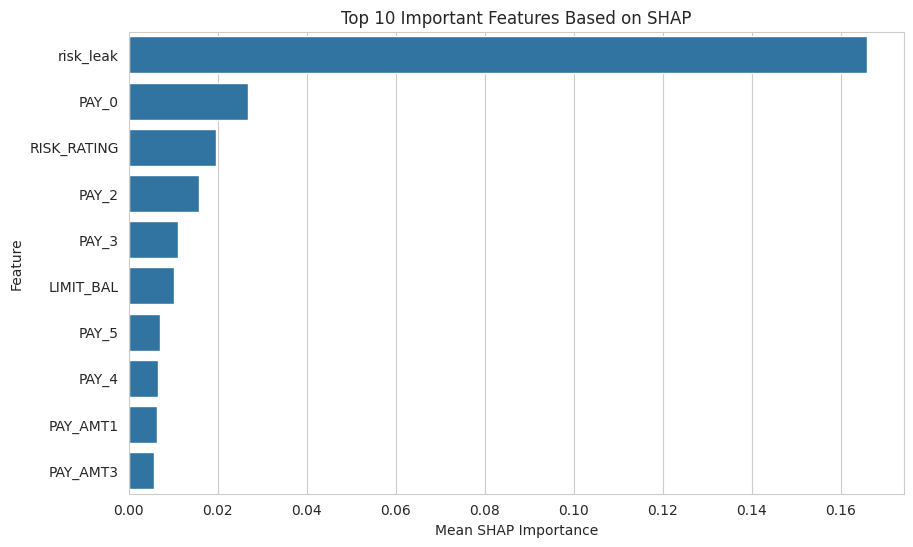

In [201]:
# Plot top 10 SHAP features

top_features = shap_importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top 10 Important Features Based on SHAP')

plt.xlabel('Mean SHAP Importance')

plt.ylabel('Feature')

plt.show()

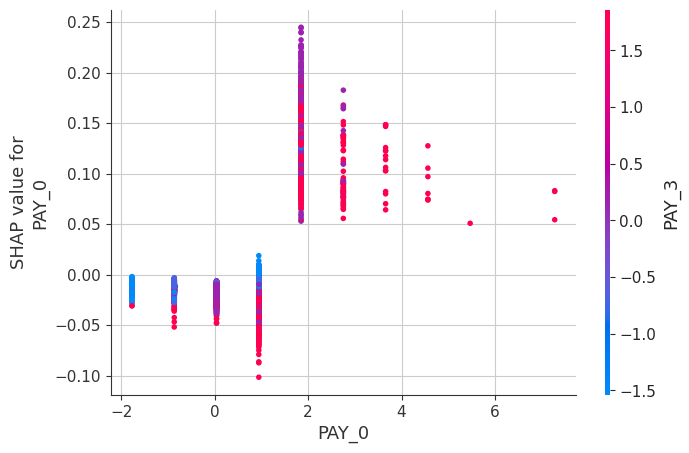

In [202]:
# SHAP dependence plot for PAY_0

shap.dependence_plot(
    'PAY_0',
    shap_values[:,:,1],
    X_test_scaled
)

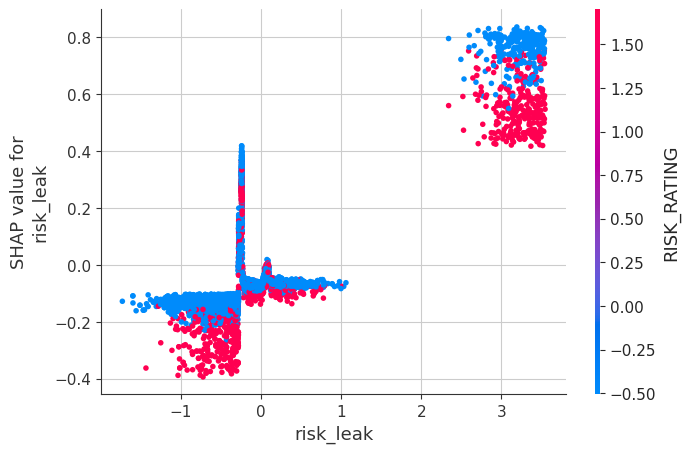

In [203]:
# SHAP dependence plot for risk_leak

shap.dependence_plot(
    'risk_leak',
    shap_values[:,:,1],
    X_test_scaled
)

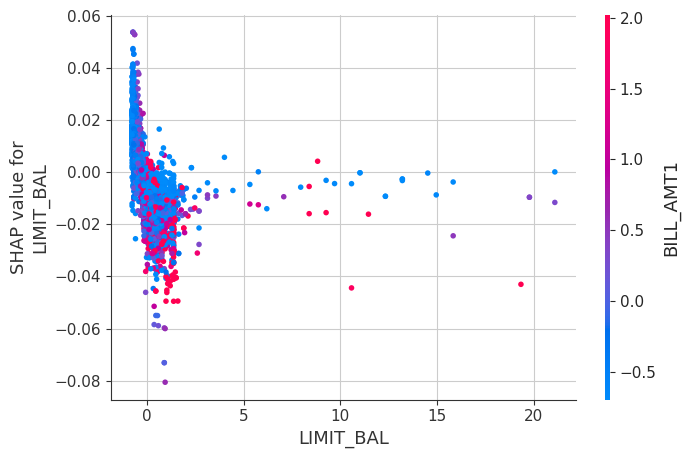

In [204]:
# SHAP dependence plot for LIMIT_BAL

shap.dependence_plot(
    'LIMIT_BAL',
    shap_values[:,:,1],
    X_test_scaled
)

In [205]:
# SHAP force plot for first test sample

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[0][:,1],
    X_test_scaled.iloc[0]
)

In [206]:
# Display top important features

print("Top Important Features:\n")

print(shap_importance_df.head(10))

Top Important Features:

        Feature  Importance
23    risk_leak    0.165829
5         PAY_0    0.026798
27  RISK_RATING    0.019526
6         PAY_2    0.015791
7         PAY_3    0.011118
0     LIMIT_BAL    0.010261
9         PAY_5    0.007082
8         PAY_4    0.006571
17     PAY_AMT1    0.006442
19     PAY_AMT3    0.005760


In [207]:
# Key feature importance

key_features = [
    'risk_leak',
    'RISK_RATING',
    'PAY_0',
    'LIMIT_BAL',
    'BILL_AMT_SUM'
]

key_importance = shap_importance_df[
    shap_importance_df['Feature'].isin(key_features)
]

key_importance

,Feature,Importance
23,risk_leak,0.165829
5,PAY_0,0.026798
27,RISK_RATING,0.019526
0,LIMIT_BAL,0.010261
24,BILL_AMT_SUM,0.005541


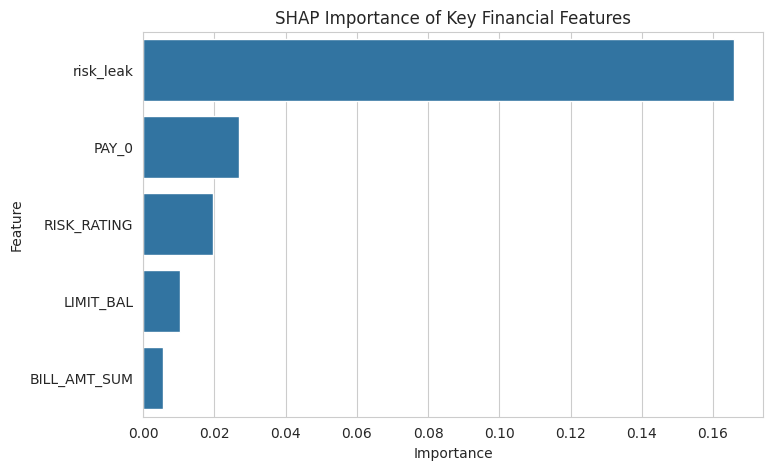

In [208]:
# Plot key feature importance

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=key_importance
)

plt.title('SHAP Importance of Key Financial Features')

plt.xlabel('Importance')

plt.ylabel('Feature')

plt.show()